# 02 — Event study

Phase 3. Quantifies how the Brent–WTI spread behaves around Middle East supply shocks.

**Design.** For each event with announcement date `T`:
- **Estimation window** `[T−80, T−20]` (60 trading days) — pre-event baseline mean μ and std σ of the dollar spread. It ends 20 days *before* the event so the run-up is visible rather than absorbed into the baseline.
- **Display window** `[T−20, T+60]` (81 trading days) — the plotted path.
- **Peak/renorm horizon** `[0, +PEAK_HORIZON]` (20 trading days) — metrics are computed on this *tight* post-event window, not the full +60. The +60 display window is long enough that, for early-2020 events, it runs into the COVID oil crash; scanning it for the max |z| attributes unrelated later moves to the event (e.g. Soleimani's apparent z≈−16 at +60 is the March-2020 crash, not the January assassination). The tight horizon isolates the genuine event response.
- **Spread-z path** `z_t = (spread_t − μ) / σ` on the dollar spread (Brent − WTI) — the tradeable quantity and the same definition the Phase-4 backtest triggers on.
- **Censoring** — events whose window overlaps a known unrelated shock are masked from that date on (see `CENSOR`), so neither the plot nor the metrics are contaminated.

**Events (locked in ROADMAP):**

| Date | Event | Role |
|------|-------|------|
| 2019-09-16 | Aramco Abqaiq drone strike | historical comparable |
| 2020-01-03 | Soleimani assassination | historical comparable (window censored pre-COVID) |
| 2024-01-19 | Houthi Red Sea escalation | ambient-escalation control |
| 2026-02-28 | Operation Epic Fury (conflict start) | **primary focal event, t=0** |
| 2026-03-04 | Strait of Hormuz closure | secondary anchor (supply-shock trigger) |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="paper", palette="deep")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(REPO / "data" / "processed" / "spread.csv", parse_dates=["date"]).set_index("date")
df = df.sort_index()

EVENTS = {
    "Aramco 2019":   "2019-09-16",
    "Soleimani 2020": "2020-01-03",
    "Houthi 2024":   "2024-01-19",
    "Epic Fury 2026": "2026-02-28",
    "Hormuz 2026":   "2026-03-04",
}

# Mask each event's window on/after this date to exclude unrelated later shocks.
CENSOR = {
    "Soleimani 2020": "2020-02-21",  # COVID oil crash begins early March 2020
}

PRE_LEN = 60       # estimation-window length (trading days)
PRE_GAP = 20       # gap between estimation window and event
WIN_PRE = 20       # display window starts T-20
WIN_POST = 60      # display window ends T+60
PEAK_HORIZON = 20  # metrics computed on the clean [0, +20] post-event window
print(f"data {df.index.min().date()} → {df.index.max().date()}; {len(EVENTS)} events")

data 1987-05-20 → 2026-05-26; 5 events


## Build spread-z paths on a common event-day axis

In [2]:
def event_pos(date_str: str) -> int:
    """Index position of the first trading day on/after the event date."""
    return int(df.index.searchsorted(pd.Timestamp(date_str)))


offsets = np.arange(-WIN_PRE, WIN_POST + 1)
z_paths = pd.DataFrame(index=offsets)
spread_paths = pd.DataFrame(index=offsets)
baselines = {}

for name, date_str in EVENTS.items():
    pos = event_pos(date_str)
    # Estimation window [T-80, T-20): mean/std of the dollar spread.
    est = df["spread"].iloc[pos - PRE_GAP - PRE_LEN : pos - PRE_GAP]
    mu, sigma = est.mean(), est.std(ddof=1)
    baselines[name] = {"baseline μ": mu, "baseline σ": sigma}

    lo, hi = max(pos - WIN_PRE, 0), min(pos + WIN_POST + 1, len(df))
    seg = df["spread"].iloc[lo:hi]
    rel = np.arange(lo, hi) - pos  # event-day offsets
    s = pd.Series(seg.values, index=rel)

    # Censor any tail that runs into an unrelated later shock.
    if name in CENSOR:
        cutoff_off = event_pos(CENSOR[name]) - pos
        s = s[s.index < cutoff_off]

    spread_paths[name] = s.reindex(offsets)
    z_paths[name] = (s.reindex(offsets) - mu) / sigma

pd.DataFrame(baselines).T.round(2)

,baseline μ,baseline σ
Aramco 2019,7.63,2.73
Soleimani 2020,6.07,0.72
Houthi 2024,5.05,0.91
Epic Fury 2026,4.87,1.47
Hormuz 2026,4.98,1.51


In [3]:
# Coverage check — censored / truncated windows show fewer than 81 days
coverage = z_paths.notna().sum().to_frame("days covered (of 81)")
coverage["last offset"] = [z_paths[c].last_valid_index() for c in z_paths.columns]
coverage

,days covered (of 81),last offset
Aramco 2019,81,60
Soleimani 2020,53,32
Houthi 2024,81,60
Epic Fury 2026,78,57
Hormuz 2026,76,55


## Per-event metrics

Peak spread-z and days-to-peak are measured on the clean `[0, +PEAK_HORIZON]` window. Days-to-renorm is the first offset after the peak where |z|<1 (searched across the full available, censored window). Pre/post volatility uses the dollar spread over the displayed window.

In [4]:
def event_metrics(name: str) -> dict:
    z = z_paths[name]
    # Peak = largest absolute deviation within the clean post-event horizon.
    post = z[(z.index >= 0) & (z.index <= PEAK_HORIZON)].dropna()
    peak_off = post.abs().idxmax()
    peak_z = post.loc[peak_off]
    # Days to renormalise: first offset after the peak where |z| < 1.
    after_peak = z[z.index > peak_off].dropna()
    renorm = after_peak[after_peak.abs() < 1]
    days_to_renorm = int(renorm.index[0]) if len(renorm) else np.nan

    sp = spread_paths[name]
    pre_vol = sp[sp.index < 0].std(ddof=1)
    post_vol = sp[sp.index >= 0].std(ddof=1)
    return {
        "peak |z|": round(abs(peak_z), 2),
        "peak z (signed)": round(peak_z, 2),
        "days to peak": int(peak_off),
        "days to renorm": days_to_renorm,
        "pre vol ($)": round(pre_vol, 2),
        "post vol ($)": round(post_vol, 2),
        "vol ratio": round(post_vol / pre_vol, 2),
    }


metrics = pd.DataFrame({n: event_metrics(n) for n in EVENTS}).T
metrics

,peak |z|,peak z (signed),days to peak,days to renorm,pre vol ($),post vol ($),vol ratio
Aramco 2019,0.88,-0.88,20.0,21.0,1.30,0.76,0.59
Soleimani 2020,2.95,-2.95,20.0,31.0,0.66,1.02,1.53
Houthi 2024,3.06,3.06,9.0,18.0,1.25,1.48,1.18
Epic Fury 2026,11.63,11.63,12.0,44.0,0.77,6.87,8.86
Hormuz 2026,12.50,12.50,19.0,42.0,0.89,6.93,7.75


**Read (the central finding).** Historical Middle East shocks barely moved the Brent–WTI spread: Aramco 2019 — the largest physical supply disruption of its era — shifted the spread by **less than one σ** within 20 days; Soleimani and Houthi produced only ~±3σ, mixed in sign. The 2026 episode is **categorically different**: a clean, sustained widening of ~+12σ with post-event volatility 8–9× the pre-event baseline. The historical comparables function as the null that makes 2026 stand out — supporting a *structural-break* reading rather than "another transient blow-out."

## The money plot

Every event's spread-z path on one event-day axis, with the cross-event median and IQR band (2026 paths drawn bold on top). This figure is the visual core of the paper: it shows that supply shocks did *not* historically produce a large characteristic spread response — and that 2026 departs sharply from that history.

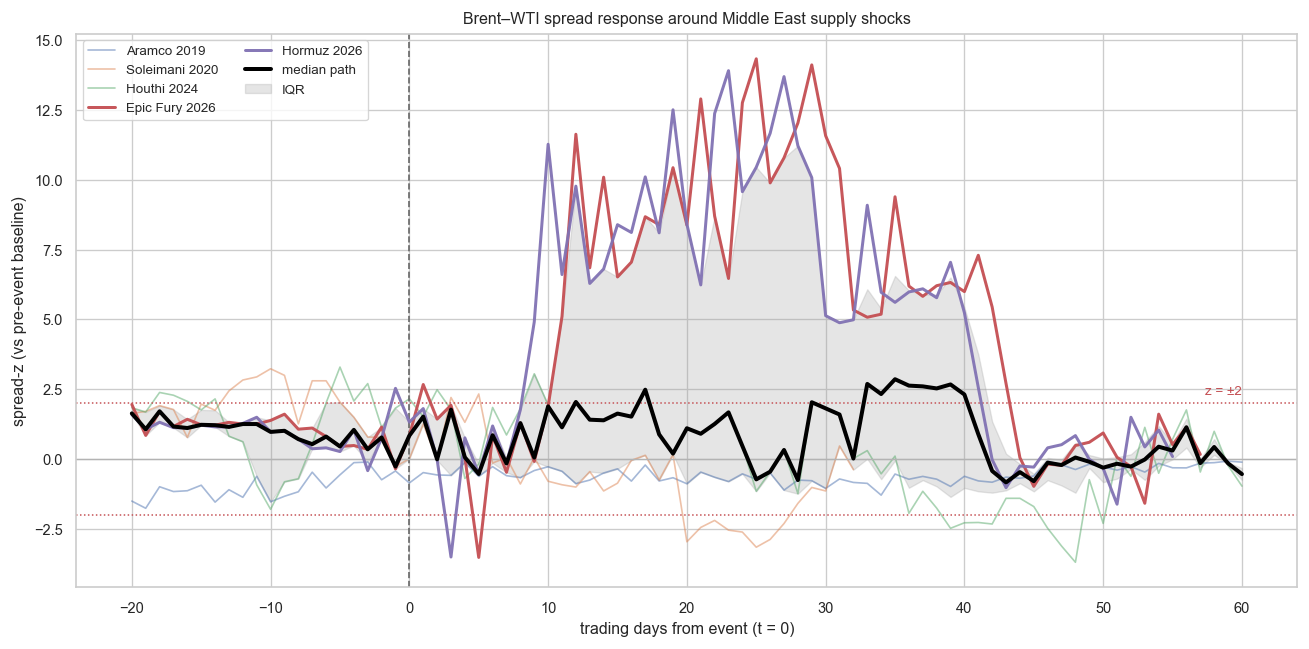

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

for name in EVENTS:
    is_2026 = "2026" in name
    ax.plot(z_paths.index, z_paths[name], lw=1.8 if is_2026 else 1.0,
            alpha=0.95 if is_2026 else 0.5,
            label=name, zorder=3 if is_2026 else 2)

median = z_paths.median(axis=1)
q25, q75 = z_paths.quantile(0.25, axis=1), z_paths.quantile(0.75, axis=1)
ax.plot(z_paths.index, median, color="black", lw=2.4, label="median path", zorder=4)
ax.fill_between(z_paths.index, q25, q75, color="0.6", alpha=0.25, label="IQR", zorder=1)

ax.axvline(0, color="0.4", ls="--", lw=1)
ax.axhline(0, color="0.7", lw=0.8)
for lvl in (2, -2):
    ax.axhline(lvl, color="C3", ls=":", lw=0.9)
ax.text(WIN_POST, 2.2, "z = ±2", color="C3", fontsize=8, ha="right", va="bottom")
ax.set_xlabel("trading days from event (t = 0)")
ax.set_ylabel("spread-z (vs pre-event baseline)")
ax.set_title("Brent–WTI spread response around Middle East supply shocks")
ax.legend(loc="upper left", fontsize=8, ncol=2)
fig.tight_layout()
fig.savefig(REPO / "paper" / "fig_money_plot.png", bbox_inches="tight")
plt.show()

## Headline event-study numbers

For the README table and the paper's event-study paragraph. The contrast between the historical comparables (muted, fast) and 2026 (large, sustained) is the short-vs-long-term spine of the thesis.

In [6]:
hist = metrics.loc[["Aramco 2019", "Soleimani 2020", "Houthi 2024"]]
focal = metrics.loc[["Epic Fury 2026", "Hormuz 2026"]]

summary = pd.Series({
    "Historical median peak |z|": round(hist["peak |z|"].median(), 2),
    "Historical max peak |z|": round(hist["peak |z|"].max(), 2),
    "2026 median peak z": round(focal["peak z (signed)"].median(), 2),
    "2026 median days-to-peak": focal["days to peak"].median(),
    "Historical median vol ratio": round(hist["vol ratio"].median(), 2),
    "2026 median vol ratio (post/pre)": round(focal["vol ratio"].median(), 2),
})
summary.to_frame("value")

,value
Historical median peak |z|,2.95
Historical max peak |z|,3.06
2026 median peak z,12.07
2026 median days-to-peak,15.50
Historical median vol ratio,1.18
2026 median vol ratio (post/pre),8.30


> **Caveats (→ Limitations).** (1) Only 3 historical comparables drive the median/IQR band — small-sample, stated honestly. (2) The peak/renorm metrics use a tight `[0,+20]` horizon to avoid contamination; the COVID crash specifically corrupts Soleimani's longer window, which is why it is censored at 2020-02-21. (3) The 2026 forward windows are **truncated** (data ends 2026-05-26), so 2026 has not been observed to renormalise in-sample — consistent with (but not proof of) the structural-repricing hypothesis tested in Phase 5. (4) Epic Fury (28 Feb) and Hormuz (4 Mar) are ~4 trading days apart, so their windows overlap heavily — treat them as one compound 2026 episode, not two independent draws. (5) **Direction matters for Phase 4:** shocks here tend to *widen* the spread (positive z), so a mean-reversion trade should be designed around fading the widening, not the ROADMAP's original `z < −2` long-spread entry — revisited in `03_backtest.ipynb`.